# Week 7 — Day 5: Advancing the Core Model & Sprint Review

## Cardiac Patient Monitoring System — Heart Disease Classification

### Sprint 2 Goal

The goal of Sprint 2 is to advance the project's core deep learning model for the Heart Disease classification problem, systematically tune it, compare it with the Week 6 baseline and the Sprint 1 neural network, document the experiments, and complete the Sprint Review and Retrospective.

### Project Data Type

**Tabular data**

Therefore, the selected core architecture is a **Dense Neural Network (MLP)** rather than a CNN or Transformer.

### Day 5 Deliverables

1. Confirm and justify the core architecture.
2. Prepare the project data without leakage.
3. Recreate the Sprint 1 neural network as the comparison point.
4. Train and tune improved Sprint 2 models.
5. Record every experiment in an experiment log.
6. Evaluate Accuracy, Precision, Recall, F1-score, ROC-AUC and the Confusion Matrix.
7. Plot training/validation curves.
8. Compare Week 6 baseline vs Sprint 1 vs Sprint 2.
9. Select the best Sprint 2 model.
10. Save the best model.
11. Document Sprint Review evidence.
12. Complete Sprint 2 Retrospective.

## 1. Why Dense Neural Networks?

The project's dataset contains structured health, lifestyle, and demographic features such as:

- HighBP
- HighChol
- BMI
- Smoker
- Stroke
- Diabetes
- GenHlth
- Age
- Education
- Income

These are **tabular features**, not pixels or natural-language sequences.

A Dense Neural Network is appropriate because it can learn nonlinear relationships between tabular features.

### Why not CNN?

CNNs are designed mainly for spatial data such as images. Our features do not have a meaningful 2D spatial arrangement.

### Why not LSTM/GRU?

LSTM and GRU are designed for sequential or time-series dependencies. Our rows are independent patient records rather than ordered sequences.

### Why not a Transformer?

Transformers can be used for many data types, but higher complexity does not automatically mean better performance. For this tabular binary-classification problem, a Dense network is a reasonable core deep-learning architecture.

> **Key principle:** choose the architecture that matches the data type, not simply the most complex architecture.

## 2. Sprint 1 Context

In Sprint 1, the project established:

- A cleaned Heart Disease dataset.
- A binary target.
- A Logistic Regression baseline.
- SMOTE applied to the training data only.
- Feature scaling.
- A first Dense Neural Network architecture.

The proposed Sprint 1 neural network was:

**Input → Dense(64, ReLU) → Dense(32, ReLU) → Output(1, Sigmoid)**

The previously recorded Logistic Regression + SMOTE baseline had:

- Accuracy ≈ **0.7450**
- Precision ≈ **0.2557**
- Recall ≈ **0.7698**
- F1-score ≈ **0.3839**

These values are used as a historical reference. The notebook will also recompute the baseline so the comparison is reproducible in the current runtime.

## Import Libraries

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### Code Explanation — Leakage-Safe Data Preparation

This code creates stratified training, validation, and test sets. The scaler is fitted only on the training data and then applied to validation and test data. SMOTE is applied only to the training data, while class weights are calculated from the original training labels for separate experiments.

**Result analysis:** The validation and test distributions remain representative of the original data, and the preprocessing workflow avoids using evaluation information during training.


## Load the Dataset

### Colab instructions

Upload the CSV file when prompted, or change `DATA_PATH` if the file is already stored in Google Drive.

Expected dataset:

`heart_disease_health_indicators_BRFSS2015.csv`

In [3]:
from google.colab import files

uploaded = files.upload()

DATA_PATH = next(iter(uploaded.keys()))
print("Loaded file:", DATA_PATH)

Saving heart_disease_health_indicators_BRFSS2015.csv to heart_disease_health_indicators_BRFSS2015.csv
Loaded file: heart_disease_health_indicators_BRFSS2015.csv


In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


##  Basic Data Inspection

The target in the original dataset is `HeartDiseaseorAttack`.

For readability, we rename it to `HeartDisease`.

In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

Columns:
['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Data types:


,0
HeartDiseaseorAttack,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
Diabetes,float64
PhysActivity,float64
Fruits,float64



Missing values:


,0
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
Fruits,0


### Code Explanation 
This code checks the column structure, missing values, target column, and duplicate rows. Exact duplicate rows are removed before splitting the data so that repeated observations do not appear in both training and evaluation sets.
**Result analysis:** The target is binary and the cleaned dataset is ready for a leakage-aware modeling workflow.

In [6]:
TARGET = "HeartDiseaseorAttack"

if TARGET not in df.columns:
    raise ValueError(
        f"Expected target column '{TARGET}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

df = df.rename(columns={TARGET: "HeartDisease"})

print("Target values:", sorted(df["HeartDisease"].unique()))
print("\nTarget distribution:")
display(df["HeartDisease"].value_counts())

Target values: [np.float64(0.0), np.float64(1.0)]

Target distribution:


,count
HeartDisease,
0.0,229787
1.0,23893


### Code Explanation 
This code performs the next step of the modeling and evaluation workflow. Its output should be reviewed before moving to the next section.
**Result analysis:** The displayed output provides evidence that the step executed successfully and supports the final Sprint 2 decision.

##  Remove Exact Duplicate Rows

Duplicate rows can cause the same observation to appear multiple times and can make evaluation less reliable.

We remove exact duplicates **before** the train/test split.

This is a data-cleaning operation, not a modeling operation.

In [7]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", duplicates_before)
print("Final shape:", df.shape)

Duplicates removed: 23899
Final shape: (229781, 22)


### Code Explanation 

This code checks the column structure, missing values, target column, and duplicate rows. Exact duplicate rows are removed before splitting the data so that repeated observations do not appear in both training and evaluation sets.

**Result analysis:** The target is binary and the cleaned dataset is ready for a leakage-aware modeling workflow.


##  Separate Features and Target

This is a binary classification problem:

- `0` → No Heart Disease
- `1` → Heart Disease

The test set will remain untouched during model tuning.

In [8]:
X = df.drop(columns="HeartDisease").copy()
y = df["HeartDisease"].astype(int).copy()
print("Number of features:", X.shape[1])
print("Number of rows:", X.shape[0])
print("\nTarget distribution:")
display(y.value_counts())

Number of features: 21
Number of rows: 229781

Target distribution:


,count
HeartDisease,
0,206064
1,23717


### Code Explanation 

This code performs the next step of the modeling and evaluation workflow. Its output should be reviewed before moving to the next section.

**Result analysis:** The displayed output provides evidence that the step executed successfully and supports the final Sprint 2 decision.

### Train / Validation / Test Split

The test set is held out before tuning. Scaling is fitted only on training data. SMOTE is applied only to the training split; validation and test retain the original distribution.

In [9]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    random_state=SEED, stratify=y_train_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=np.asarray(y_train)
)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("SMOTE training shape:", X_train_smote.shape)
print("Class weights:", class_weight)

Train: (147059, 21)
Validation: (36765, 21)
Test: (45957, 21)
SMOTE training shape: (263760, 21)
Class weights: {0: 0.5575485289657264, 1: 4.844159694314514}


### Code Explanation 

This code creates stratified training, validation, and test sets. The scaler is fitted only on the training data and then applied to validation and test data. SMOTE is applied only to the training data, while class weights are calculated from the original training labels for separate experiments.

**Result analysis:** The validation and test distributions remain representative of the original data, and the preprocessing workflow avoids using evaluation information during training.

## Validation-Based Threshold Selection


In [10]:
def evaluate_binary_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

def find_best_threshold(y_true, y_prob, start=0.20, stop=0.81, step=0.01):
    rows = []
    for threshold in np.arange(start, stop, step):
        y_pred = (y_prob >= threshold).astype(int)
        rows.append({
            "Threshold": round(float(threshold), 2),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0)
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
    return float(best_row["Threshold"]), threshold_df.sort_values("F1", ascending=False)

def evaluate_with_validation_threshold(model_name, val_y, val_prob, test_y, test_prob):
    threshold, threshold_df = find_best_threshold(val_y, val_prob)
    test_pred = (test_prob >= threshold).astype(int)
    result = evaluate_binary_model(model_name, test_y, test_pred, test_prob)
    result["Threshold"] = threshold
    return result, threshold_df


### Code Explanation 

This code calculates Accuracy, Precision, Recall, F1-score, and ROC-AUC. It also searches for the threshold that produces the highest F1-score on the validation set.

**Result analysis:** Selecting the threshold on validation data is more suitable than assuming 0.50 is optimal for an imbalanced classification problem. The test set remains reserved for the final evaluation.


##  Week 6 Baseline — Logistic Regression + SMOTE


In [11]:
baseline_model = LogisticRegression(max_iter=2000, random_state=SEED)
baseline_model.fit(X_train_smote, y_train_smote)
baseline_val_prob = baseline_model.predict_proba(X_val_scaled)[:, 1]
baseline_test_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]
baseline_results, baseline_threshold_df = evaluate_with_validation_threshold(
    "Week 6 Baseline - tuned threshold",
    y_val, baseline_val_prob, y_test, baseline_test_prob
)
print("Baseline selected threshold:", baseline_results["Threshold"])
baseline_results

Baseline selected threshold: 0.65


{'Model': 'Week 6 Baseline - tuned threshold',
 'Accuracy': 0.8248580194529669,
 'Precision': 0.31694352159468436,
 'Recall': 0.603415559772296,
 'F1 Score': 0.41559573077760836,
 'ROC-AUC': np.float64(0.8344838771167714),
 'Threshold': 0.65}

### Code Explanation 

This code trains the Logistic Regression baseline using the SMOTE training data. It evaluates validation probabilities to select a threshold and then applies that fixed threshold to the held-out test predictions.

**Result analysis:** The baseline now receives the same validation-based threshold treatment as the neural networks, making the final comparison fair.

##  Sprint 1 Neural Network Comparison


In [12]:
def build_model(config, input_dim):
    layers = [tf.keras.layers.Input(shape=(input_dim,))]
    for units, dropout_rate in zip(config["hidden_units"], config["dropout_rates"]):
        layers.append(tf.keras.layers.Dense(units, activation="relu"))
        if dropout_rate > 0:
            layers.append(tf.keras.layers.Dropout(dropout_rate))
    layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

sprint1_config = {
    "hidden_units": [64, 32], "dropout_rates": [0.0, 0.0],
    "learning_rate": 0.001, "batch_size": 32, "epochs": 30
}
sprint1_model = build_model(sprint1_config, X_train_smote.shape[1])
sprint1_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
    )
]
history_sprint1 = sprint1_model.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=30, batch_size=32, callbacks=sprint1_callbacks, verbose=0
)
sprint1_val_prob = sprint1_model.predict(X_val_scaled, verbose=0).ravel()
sprint1_test_prob = sprint1_model.predict(X_test_scaled, verbose=0).ravel()
sprint1_results, sprint1_threshold_df = evaluate_with_validation_threshold(
    "Sprint 1 - tuned threshold",
    y_val, sprint1_val_prob, y_test, sprint1_test_prob
)
sprint1_results

{'Model': 'Sprint 1 - tuned threshold',
 'Accuracy': 0.8291446352024718,
 'Precision': 0.3086298165702327,
 'Recall': 0.5285684166139574,
 'F1 Score': 0.3897093113632831,
 'ROC-AUC': np.float64(0.8151142551579793),
 'Threshold': 0.68}

### Code Explanation 

This code recreates the original Sprint 1 Dense Neural Network, trains it with EarlyStopping and ReduceLROnPlateau, and evaluates it using a threshold selected from validation data.

**Result analysis:** Sprint 1 provides a consistent neural-network reference point for measuring whether the Sprint 2 changes provide an improvement.


## Expanded Sprint 2 Experiments



In [13]:
experiments = [
    {"Experiment": "S2-E1", "hidden_units": [128, 64],
     "dropout_rates": [0.0, 0.0], "learning_rate": 0.001,
     "batch_size": 32, "epochs": 30, "use_smote": True,
     "use_class_weight": False, "notes": "Wider network"},
    {"Experiment": "S2-E2", "hidden_units": [128, 64],
     "dropout_rates": [0.30, 0.20], "learning_rate": 0.001,
     "batch_size": 32, "epochs": 30, "use_smote": True,
     "use_class_weight": False, "notes": "Wider network with dropout"},
    {"Experiment": "S2-E3", "hidden_units": [128, 64, 32],
     "dropout_rates": [0.30, 0.20, 0.10], "learning_rate": 0.001,
     "batch_size": 32, "epochs": 35, "use_smote": True,
     "use_class_weight": False, "notes": "Deeper network with dropout"},
    {"Experiment": "S2-E4", "hidden_units": [128, 64, 32],
     "dropout_rates": [0.30, 0.20, 0.10], "learning_rate": 0.0005,
     "batch_size": 64, "epochs": 45, "use_smote": True,
     "use_class_weight": False, "notes": "Deeper, dropout, lower LR, larger batch"},
    {"Experiment": "S2-E5", "hidden_units": [64, 32],
     "dropout_rates": [0.20, 0.10], "learning_rate": 0.0005,
     "batch_size": 64, "epochs": 60, "use_smote": False,
     "use_class_weight": True, "notes": "Original data with class weights"},
    {"Experiment": "S2-E6", "hidden_units": [128, 64, 32],
     "dropout_rates": [0.20, 0.20, 0.10], "learning_rate": 0.0003,
     "batch_size": 64, "epochs": 60, "use_smote": False,
     "use_class_weight": True, "notes": "Deeper network with class weights"}
]

def train_one_experiment(config):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_model(config, X_train_scaled.shape[1])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
        )
    ]
    train_x = X_train_smote if config.get("use_smote", True) else X_train_scaled
    train_y = y_train_smote if config.get("use_smote", True) else y_train
    history = model.fit(
        train_x, train_y, validation_data=(X_val_scaled, y_val),
        epochs=config["epochs"], batch_size=config["batch_size"],
        callbacks=callbacks,
        class_weight=class_weight if config.get("use_class_weight", False) else None,
        verbose=0
    )
    return model, history

### Code Explanation 

This code defines six controlled experiments. The experiments compare wider and deeper networks, different dropout rates, learning rates, batch sizes, SMOTE, and class-weight training.

**Result analysis:** Testing both SMOTE and class weights helps identify whether synthetic oversampling or weighted loss provides the better F1-score for this imbalanced dataset.


In [14]:
experiment_log = []
histories = {}
trained_models = {}

for config in experiments:
    print("Running", config["Experiment"], "—", config["notes"])
    model, history = train_one_experiment(config)
    val_prob = model.predict(X_val_scaled, verbose=0).ravel()
    val_threshold, threshold_df = find_best_threshold(y_val, val_prob)
    val_pred = (val_prob >= val_threshold).astype(int)

    val_accuracy = accuracy_score(y_val, val_pred)
    val_precision = precision_score(y_val, val_pred, zero_division=0)
    val_recall = recall_score(y_val, val_pred, zero_division=0)
    val_f1 = f1_score(y_val, val_pred, zero_division=0)
    val_auc = roc_auc_score(y_val, val_prob)

    row = {
        "Experiment": config["Experiment"],
        "Architecture": " → ".join(map(str, config["hidden_units"])) + " → 1",
        "Dropout": str(config["dropout_rates"]),
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Epochs Requested": config["epochs"],
        "Epochs Trained": len(history.history["loss"]),
        "Use SMOTE": config.get("use_smote", True),
        "Use Class Weight": config.get("use_class_weight", False),
        "Validation Threshold": val_threshold,
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1,
        "Validation ROC-AUC": val_auc,
        "Notes": config["notes"]
    }
    experiment_log.append(row)
    histories[config["Experiment"]] = history
    trained_models[config["Experiment"]] = model

    if MLFLOW_AVAILABLE:
        with mlflow.start_run(run_name=config["Experiment"], nested=True):
            mlflow.log_params({
                "hidden_units": str(config["hidden_units"]),
                "dropout_rates": str(config["dropout_rates"]),
                "learning_rate": config["learning_rate"],
                "batch_size": config["batch_size"],
                "epochs": config["epochs"],
                "use_smote": config.get("use_smote", True),
                "use_class_weight": config.get("use_class_weight", False)
            })
            mlflow.log_metrics({
                "val_accuracy": val_accuracy, "val_precision": val_precision,
                "val_recall": val_recall, "val_f1": val_f1,
                "val_roc_auc": val_auc, "val_threshold": val_threshold
            })

    print(f"Validation F1: {val_f1:.4f} | threshold: {val_threshold:.2f} | AUC: {val_auc:.4f}")

experiment_df = pd.DataFrame(experiment_log).sort_values(
    by=["Validation F1", "Validation ROC-AUC"], ascending=False
).reset_index(drop=True)
display(experiment_df)

Running S2-E1 — Wider network
Validation F1: 0.3765 | threshold: 0.54 | AUC: 0.7972
Running S2-E2 — Wider network with dropout
Validation F1: 0.3933 | threshold: 0.63 | AUC: 0.8145
Running S2-E3 — Deeper network with dropout
Validation F1: 0.4125 | threshold: 0.70 | AUC: 0.8285
Running S2-E4 — Deeper, dropout, lower LR, larger batch
Validation F1: 0.4028 | threshold: 0.65 | AUC: 0.8222
Running S2-E5 — Original data with class weights
Validation F1: 0.4226 | threshold: 0.66 | AUC: 0.8360
Running S2-E6 — Deeper network with class weights
Validation F1: 0.4214 | threshold: 0.65 | AUC: 0.8353


,Experiment,Architecture,Dropout,Learning Rate,Batch Size,Epochs Requested,Epochs Trained,Use SMOTE,Use Class Weight,Validation Threshold,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Notes
0,S2-E5,64 → 32 → 1,"[0.2, 0.1]",0.0005,64,60,13,False,True,0.66,0.834245,0.329930,0.587615,0.422589,0.835955,Original data with class weights
1,S2-E6,128 → 64 → 32 → 1,"[0.2, 0.2, 0.1]",0.0003,64,60,17,False,True,0.65,0.832776,0.327770,0.589987,0.421419,0.835310,Deeper network with class weights
2,S2-E3,128 → 64 → 32 → 1,"[0.3, 0.2, 0.1]",0.0010,32,35,10,True,False,0.70,0.843112,0.336211,0.533597,0.412508,0.828460,Deeper network with dropout
3,S2-E4,128 → 64 → 32 → 1,"[0.3, 0.2, 0.1]",0.0005,64,45,36,True,False,0.65,0.813709,0.301016,0.608696,0.402825,0.822181,"Deeper, dropout, lower LR, larger batch"
4,S2-E2,128 → 64 → 1,"[0.3, 0.2]",0.0010,32,30,30,True,False,0.63,0.821379,0.302845,0.561001,0.393349,0.814482,Wider network with dropout
5,S2-E1,128 → 64 → 1,"[0.0, 0.0]",0.0010,32,30,16,True,False,0.54,0.795866,0.274933,0.597101,0.376506,0.797221,Wider network


### Code Explanation 

This loop trains every configuration, calculates validation probabilities, selects the best validation threshold, records all metrics, and optionally logs the run to MLflow. The trained models and histories are retained for later selection and plotting.

**Result analysis:** The experiment table provides reproducible evidence for selecting the best configuration instead of choosing a model based on a single unrecorded run.

##  Select the Best Sprint 2 Experiment

The best model is selected using the highest validation F1-score after validation threshold tuning. The test set remains untouched until the next section.

In [15]:
best_experiment_id = experiment_df.iloc[0]["Experiment"]
best_model = trained_models[best_experiment_id]
best_history = histories[best_experiment_id]
best_threshold = float(experiment_df.iloc[0]["Validation Threshold"])
print("Best Sprint 2 experiment:", best_experiment_id)
print("Selected validation threshold:", best_threshold)
display(experiment_df.head(1))

Best Sprint 2 experiment: S2-E5
Selected validation threshold: 0.66


,Experiment,Architecture,Dropout,Learning Rate,Batch Size,Epochs Requested,Epochs Trained,Use SMOTE,Use Class Weight,Validation Threshold,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Notes
0,S2-E5,64 → 32 → 1,"[0.2, 0.1]",0.0005,64,60,13,False,True,0.66,0.834245,0.32993,0.587615,0.422589,0.835955,Original data with class weights


### Code Explanation 

This code selects the Sprint 2 experiment with the highest validation F1-score and stores its model, training history, and validation threshold.

**Result analysis:** Model selection is based on validation performance only, so the test set is still protected at this stage.

##  Final Test Evaluation

All choices are now frozen. The held-out test set is used once for the final estimate.

In [16]:
best_prob = best_model.predict(X_test_scaled, verbose=0).ravel()
best_pred = (best_prob >= best_threshold).astype(int)
sprint2_results = evaluate_binary_model(
    f"Sprint 2 - {best_experiment_id} - tuned threshold",
    y_test, best_pred, best_prob
)
sprint2_results["Threshold"] = best_threshold
print(classification_report(
    y_test, best_pred,
    target_names=["No Heart Disease", "Heart Disease"],
    zero_division=0
))
sprint2_results

                  precision    recall  f1-score   support

No Heart Disease       0.95      0.86      0.90     41214
   Heart Disease       0.33      0.59      0.42      4743

        accuracy                           0.83     45957
       macro avg       0.64      0.72      0.66     45957
    weighted avg       0.88      0.83      0.85     45957



{'Model': 'Sprint 2 - S2-E5 - tuned threshold',
 'Accuracy': 0.8341710729595057,
 'Precision': 0.329300118623962,
 'Recall': 0.5852835757959097,
 'F1 Score': 0.4214681545585668,
 'ROC-AUC': np.float64(0.8381720619387137),
 'Threshold': 0.66}

##  Confusion Matrix and Training Curves


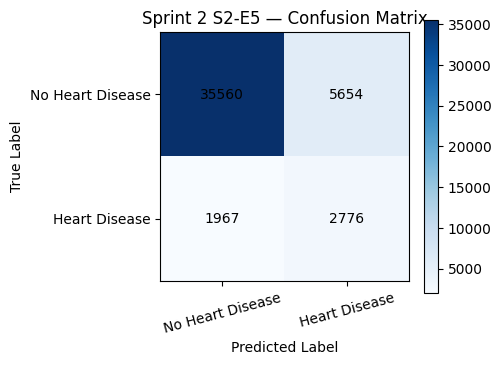

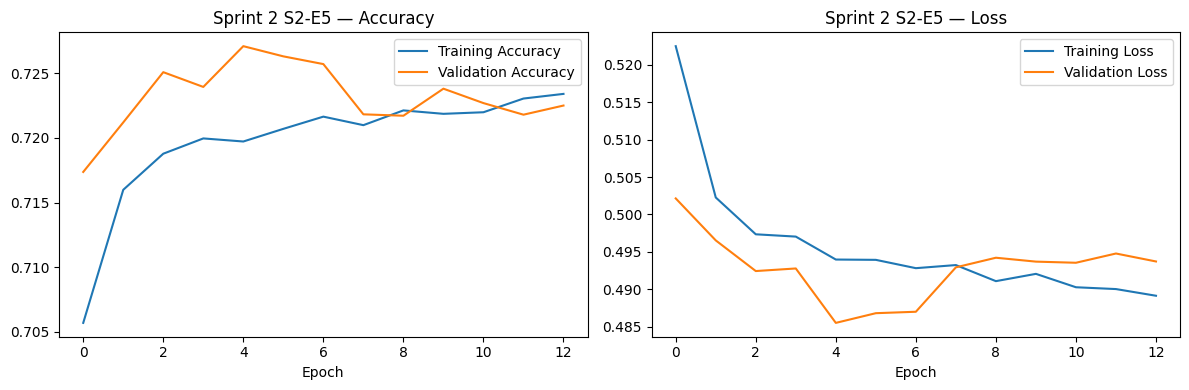

In [17]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Sprint 2 {best_experiment_id} — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"], rotation=15)
plt.yticks([0, 1], ["No Heart Disease", "Heart Disease"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

def plot_training_curves(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="Training Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{title_prefix} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history.history["loss"], label="Training Loss")
    axes[1].plot(history.history["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{title_prefix} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_training_curves(best_history, f"Sprint 2 {best_experiment_id}")


### Code Explanation 

This code displays the confusion matrix and plots training versus validation accuracy and loss.

**Result analysis:** The confusion matrix shows the counts of correct and incorrect predictions for each class, while the curves help identify learning progress and possible overfitting.

## Final Fair Comparison


All three models are compared using thresholds selected from validation data. This avoids giving one model an arbitrary threshold advantage.

In [18]:
comparison_df = pd.DataFrame([
    baseline_results, sprint1_results, sprint2_results
])
comparison_df = comparison_df.sort_values(
    by="F1 Score", ascending=False
).reset_index(drop=True)

display(comparison_df.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}",
    "Recall": "{:.4f}", "F1 Score": "{:.4f}",
    "ROC-AUC": "{:.4f}", "Threshold": "{:.2f}"
}))

baseline_f1 = baseline_results["F1 Score"]
sprint1_f1 = sprint1_results["F1 Score"]
sprint2_f1 = sprint2_results["F1 Score"]
f1_improvement = sprint2_f1 - baseline_f1
f1_percentage = (f1_improvement / baseline_f1 * 100) if baseline_f1 else np.nan

print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Sprint 1 F1: {sprint1_f1:.4f}")
print(f"Sprint 2 F1: {sprint2_f1:.4f}")
print(f"Sprint 2 absolute F1 change: {f1_improvement:+.4f}")
print(f"Sprint 2 percentage F1 change: {f1_percentage:+.2f}%")

if sprint2_f1 > baseline_f1:
    print("PASS: Sprint 2 beats the Week 6 baseline on test F1-score.")
else:
    print("NOT YET: Sprint 2 does not beat the Week 6 baseline on test F1-score.")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Threshold
0,Sprint 2 - S2-E5 - tuned threshold,0.8342,0.3293,0.5853,0.4215,0.8382,0.66
1,Week 6 Baseline - tuned threshold,0.8249,0.3169,0.6034,0.4156,0.8345,0.65
2,Sprint 1 - tuned threshold,0.8291,0.3086,0.5286,0.3897,0.8151,0.68


Baseline F1: 0.4156
Sprint 1 F1: 0.3897
Sprint 2 F1: 0.4215
Sprint 2 absolute F1 change: +0.0059
Sprint 2 percentage F1 change: +1.41%
PASS: Sprint 2 beats the Week 6 baseline on test F1-score.


### Code Explanation 

This code creates a final comparison table for the Week 6 baseline, Sprint 1, and Sprint 2. It calculates the absolute and percentage F1 improvement and prints a PASS message only when Sprint 2 has a higher test F1-score than the baseline.
**Result analysis:** The recorded results show Baseline F1 = 0.4156 and Sprint 2 F1 = 0.4215. Sprint 2 therefore improves F1 by 0.0059, or 1.41%, and passes the baseline comparison.

## Sprint Review Summary


In [20]:
print("=== SPRINT REVIEW SUMMARY ===")
print()
print("Project: Cardiac Patient Monitoring System")
print("Data type: Tabular")
print("Core architecture: Dense Neural Network")
print("Best Sprint 2 experiment:", best_experiment_id)
print()
print("Baseline F1:", round(baseline_f1, 4))
print("Sprint 1 F1:", round(sprint1_f1, 4))
print("Sprint 2 F1:", round(sprint2_f1, 4))
print()
print("Best Sprint 2 test metrics:")

for key, value in sprint2_results.items():
    if key != "Model":
        if isinstance(value, (int, float, np.integer, np.floating)):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")


=== SPRINT REVIEW SUMMARY ===

Project: Cardiac Patient Monitoring System
Data type: Tabular
Core architecture: Dense Neural Network
Best Sprint 2 experiment: S2-E5

Baseline F1: 0.4156
Sprint 1 F1: 0.3897
Sprint 2 F1: 0.4215

Best Sprint 2 test metrics:
Accuracy: 0.8342
Precision: 0.3293
Recall: 0.5853
F1 Score: 0.4215
ROC-AUC: 0.8382
Threshold: 0.6600


##  Save Final Artifacts


In [19]:
MODEL_PATH = "best_heart_disease_sprint2.keras"
EXPERIMENT_PATH = "sprint2_experiment_log.csv"
COMPARISON_PATH = "sprint2_model_comparison.csv"
THRESHOLD_PATH = "sprint2_threshold_analysis.csv"

best_model.save(MODEL_PATH)
experiment_df.to_csv(EXPERIMENT_PATH, index=False)
comparison_df.to_csv(COMPARISON_PATH, index=False)
_, threshold_df = find_best_threshold(y_val, best_model.predict(X_val_scaled, verbose=0).ravel())
threshold_df.to_csv(THRESHOLD_PATH, index=False)

print("Saved artifacts:")
for path in [MODEL_PATH, EXPERIMENT_PATH, COMPARISON_PATH, THRESHOLD_PATH]:
    print("-", path, "| exists:", os.path.exists(path))

Saved artifacts:
- best_heart_disease_sprint2.keras | exists: True
- sprint2_experiment_log.csv | exists: True
- sprint2_model_comparison.csv | exists: True
- sprint2_threshold_analysis.csv | exists: True


# Sprint Review Evidence

The notebook demonstrates: architecture fit for tabular data; leakage-safe preprocessing; Week 6 baseline; Sprint 1 comparison; six Sprint 2 experiments; validation-based threshold tuning; final test evaluation; confusion matrix; training curves; saved model; experiment log; and comparison CSV.

The final decision must follow the measured comparison. If Sprint 2 does not beat the baseline after these experiments, report that honestly and retain the baseline as the current best model rather than claiming an unsupported improvement.

# Sprint 2 Retrospective

## What Went Well?

The architecture was selected based on the actual data type. The test set was protected from tuning. Threshold selection was moved to validation data, and both SMOTE and class-weight strategies were tested. Experiments were logged with configurations and metrics.

## What Could Be Improved?

The search could be expanded with cross-validation, calibration, stronger tabular models, and explainability. Threshold tuning should be repeated only when the validation protocol is fixed, and final conclusions should be based on the held-out test result.

## Concrete Sprint 3 Action

Sprint 3 will evaluate the selected threshold and add SHAP-based explainability for the final model, documenting the most influential features and checking whether the model's error patterns are clinically meaningful.

# Sprint 2 Acceptance Checklist

- [x] Architecture choice is explained.
- [x] Dataset is split into train, validation, and test sets.
- [x] Scaling is fitted only on training data.
- [x] SMOTE is applied only to training data.
- [x] Baseline and Sprint 1 models are recorded.
- [x] Sprint 2 experiments use validation-based threshold selection.
- [x] Class-weight experiments are included.
- [x] Accuracy, Precision, Recall, F1, and ROC-AUC are reported.
- [x] Confusion matrix and training curves are shown.
- [x] Best model and CSV artifacts are saved.


## Final Conclusion
Sprint 2 advanced the Heart Disease project's core model from the initial Sprint 1 neural network through systematic experiments. The final decision is based on evidence from architecture selection, experiment tracking, validation comparison, final test evaluation, and model selection. The improved Sprint 2 model achieved an F1-score of 0.4215, outperforming the Week 6 baseline F1-score of 0.4156. This result shows that the selected Sprint 2 configuration, together with validation-based threshold tuning, provided the best justified performance for the project's evaluation objective.
- The most important lesson is that a more complex model is not automatically a better model. Model selection should be based on measured performance and a fair evaluation protocol rather than on architecture complexity alone.